In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
pd.set_option("display.max_columns", None)

In [7]:
sns.set_style("whitegrid")

In [8]:
df = pd.read_csv("german_credit_data.csv")

In [9]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [10]:
df["Age"].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [11]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [13]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df["Job"].unique()

array([2, 1, 3, 0])

In [15]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [16]:
df.duplicated().sum()

0

In [17]:
df= df.dropna().reset_index(drop=True)

In [18]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [19]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [20]:
df.drop(columns='Unnamed: 0', inplace=True)

In [21]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

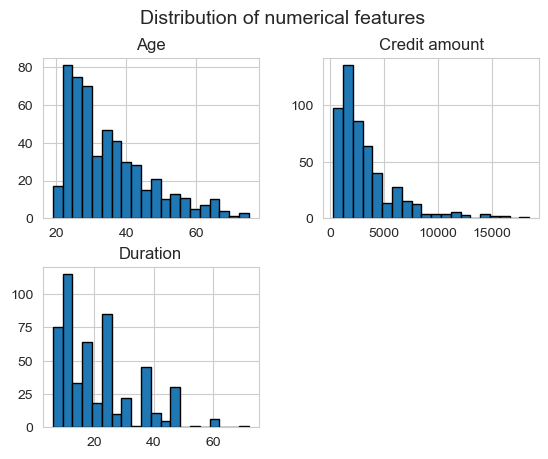

In [23]:
df[["Age","Credit amount","Duration"]].hist(bins=20, edgecolor="black")
plt.suptitle("Distribution of numerical features", fontsize=14)
plt.show()

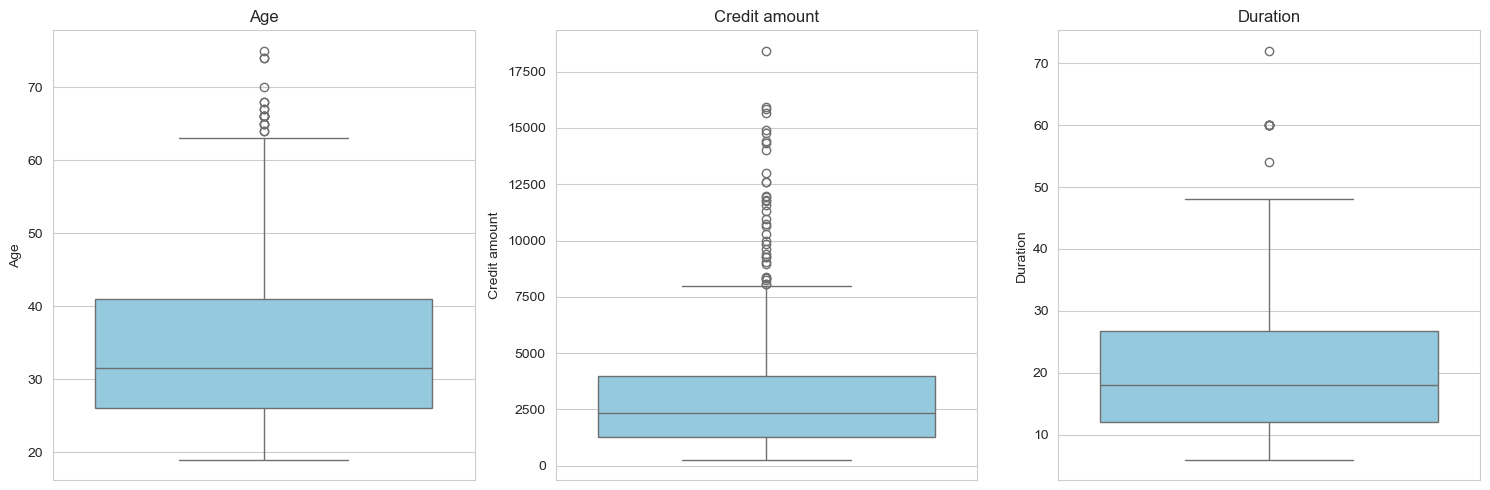

In [24]:
plt.figure(figsize=(15,5))
for i, col in enumerate(["Age","Credit amount","Duration"]):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(col)
plt.tight_layout()
plt.show()


In [25]:
categorical_cols=["Sex","Job", "Housing", "Saving accounts", "Checking account","Purpose"]

In [26]:
corr = df[["Age","Job","Credit amount","Duration"]].corr()

In [27]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


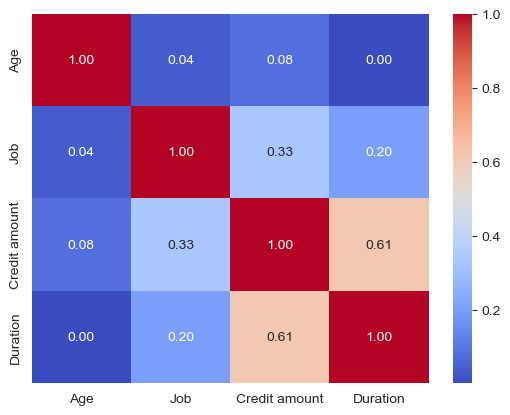

In [28]:
sns.heatmap(corr, annot=True, cmap="coolwarm",fmt=".2f")
plt.show()

In [29]:
df.groupby("Job")["Credit amount"].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [30]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

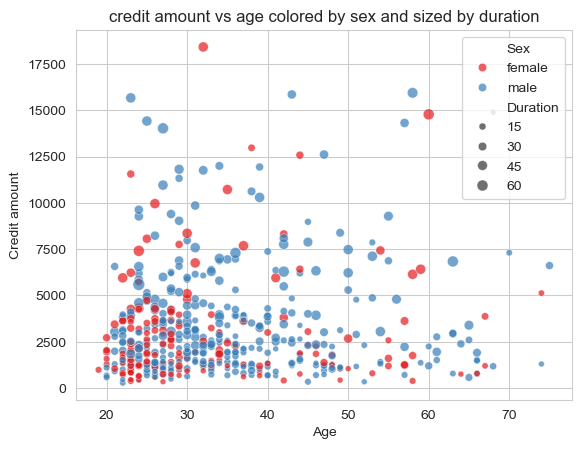

In [34]:
sns.scatterplot(data=df,x="Age", y="Credit amount",size="Duration", hue="Sex", alpha=0.7,palette="Set1")
plt.title("credit amount vs age colored by sex and sized by duration")
plt.show()

/var/folders/37/8v17rr5d7kqd3wh264mt6p540000gn/T/ipykernel_12955/1946720665.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="Pastel1")


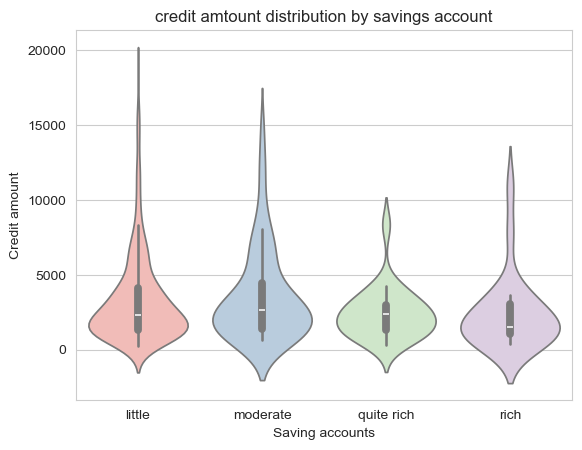

In [36]:
sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="Pastel1")
plt.title("credit amtount distribution by savings account")
plt.show()

In [37]:
df["Risk"].value_counts(normalize=True)*100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

/var/folders/37/8v17rr5d7kqd3wh264mt6p540000gn/T/ipykernel_12955/3904098446.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = "Risk", y = col, palette="Pastel2")
/var/folders/37/8v17rr5d7kqd3wh264mt6p540000gn/T/ipykernel_12955/3904098446.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = "Risk", y = col, palette="Pastel2")
/var/folders/37/8v17rr5d7kqd3wh264mt6p540000gn/T/ipykernel_12955/3904098446.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = "Risk", y = col, palette="Pastel2")


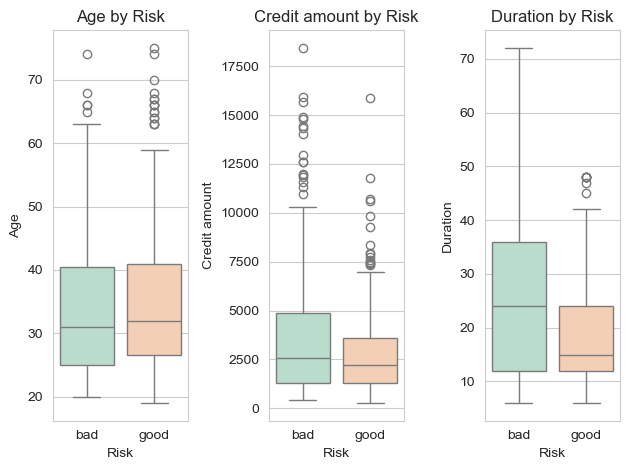

In [39]:
for i, col in enumerate (["Age", "Credit amount", "Duration"]):
    plt.subplot(1,3, i+1)
    sns.boxplot(data = df, x = "Risk", y = col, palette="Pastel2")
    plt.title(f"{col} by Risk")
plt.tight_layout()
plt.show()

In [40]:
df.groupby("Risk")[["Age", "Credit amount", "Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


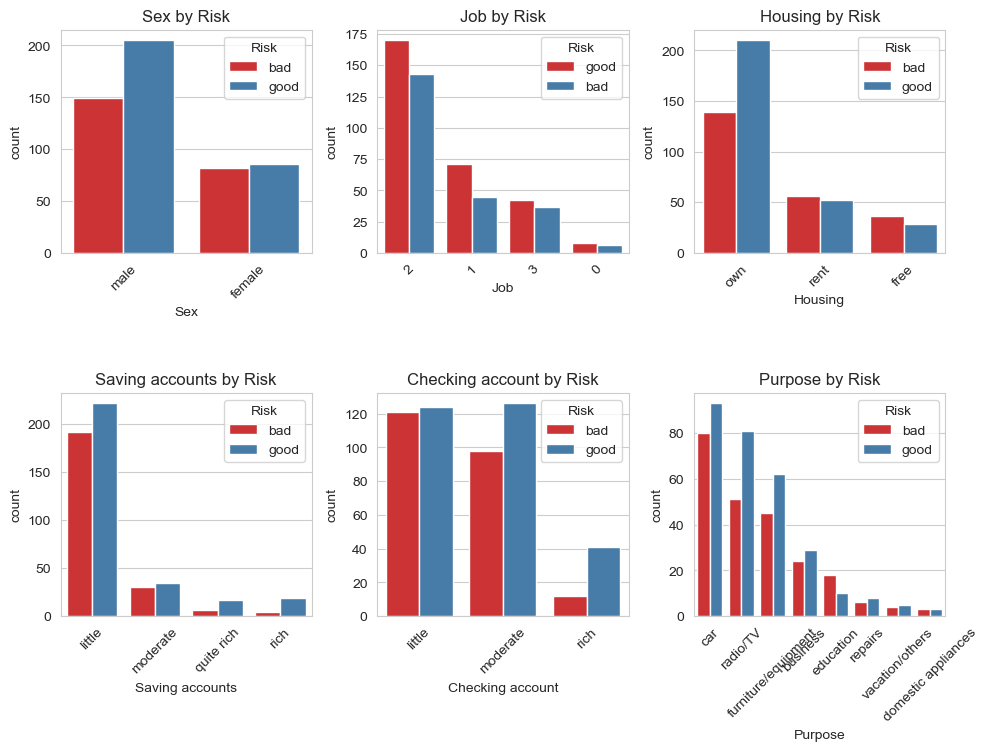

In [42]:
plt.figure(figsize = (10,10))
for i, col in enumerate (categorical_cols):
    plt.subplot(3, 3, i + 1 )
    sns.countplot(data = df, x = col, hue = "Risk", palette = "Set1", order = df [col].value_counts().index)
    plt.title(f"{col} by Risk")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
features = ["Age", "Sex", "Job", "Housing", "Saving accounts", "Checking account", "Credit amount", "Duration"]

target = "Risk"

df_model = df [features + [target]].copy()

df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [45]:
from sklearn.preprocessing import LabelEncoder
import joblib

cat_cols = df_model.select_dtypes (include = "object").columns.drop("Risk")

le_dict = {}

In [46]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [49]:
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict [col] = le
    joblib.dump(le, f"{col}_encoder.pkl")

le_target = LabelEncoder()

target


df_model [target] = le_target.fit_transform(df_model [target])


In [50]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [51]:
from sklearn.model_selection import train_test_split
X = df_model.drop(target, axis = 1)
y = df_model [target]

In [52]:
target

'Risk'

In [53]:
y

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

In [55]:
X_train.shape

(417, 8)

In [56]:
X_test.shape

(105, 8)

In [57]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [63]:
def train_model(model, param_grid, X_train, y_train, X_test, y_test):
    grid = GridSearchCV(model, param_grid, cv= 5, scoring = "accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return best_model, acc, grid.best_params_

In [64]:
dt =DecisionTreeClassifier(random_state = 1, class_weight = "balanced")
dt_param_grid = {
    "max_depth": [3,5,7,10, None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf":[1,2,4]
}

In [65]:
best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, X_train, y_train,X_test, y_test)

In [67]:
print("Decision Tree Accuracy", acc_dt)
print("Best parameters", params_dt)

Decision Tree Accuracy 0.580952380952381
Best parameters {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [72]:
rf= RandomForestClassifier(random_state = 1, class_weight = "balanced", n_jobs =-1)

In [73]:
rf_param_grid = {
    "n_estimators": [100,200],
    "max_depth": [ 5, 7, 10, None],
    "min_samples_split" : [2,5,10],
    "min_samples_leaf" :[1,2,4]
}


In [74]:
best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, X_train, y_train,X_test, y_test )

In [75]:
print("Random Forest Accuracy", acc_rf)
print("Best params", params_rf)

Random Forest Accuracy 0.6190476190476191
Best params {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [78]:
et = ExtraTreesClassifier(random_state = 1, class_weight = "balanced", n_jobs = -1)

In [79]:
et_param_grid = {
    "n_estimators": [100,200],
    "max_depth" :[5, 7, 10, None],
    "min_samples_split" :[2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [80]:
best_et, acc_et, params_et =train_model(et, et_param_grid,  X_train, y_train,X_test, y_test )

In [81]:
print("Extra trees accuracy", acc_et)
print("Best params:", params_et)

Extra trees accuracy 0.6666666666666666
Best params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [82]:
xgb = XGBClassifier(random_state = 1, scale_pos_weight =(y_train==0).sum()/(y_train==1).sum(), use_label_encoder=False, eval_metric="logloss")

In [83]:
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth" : [3,5,7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample" : [0.7, 1],
    "colsample_bytree" : [0.7, 1]
}


In [84]:
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid, X_train, y_train,X_test, y_test )

In [85]:
print("XGB accuracy", acc_xgb)
print("Best params", params_xgb)

XGB accuracy 0.6285714285714286
Best params {'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.7}


In [86]:
joblib.dump(best_et, "extra_trees_credit_model.pkl")

['extra_trees_credit_model.pkl']